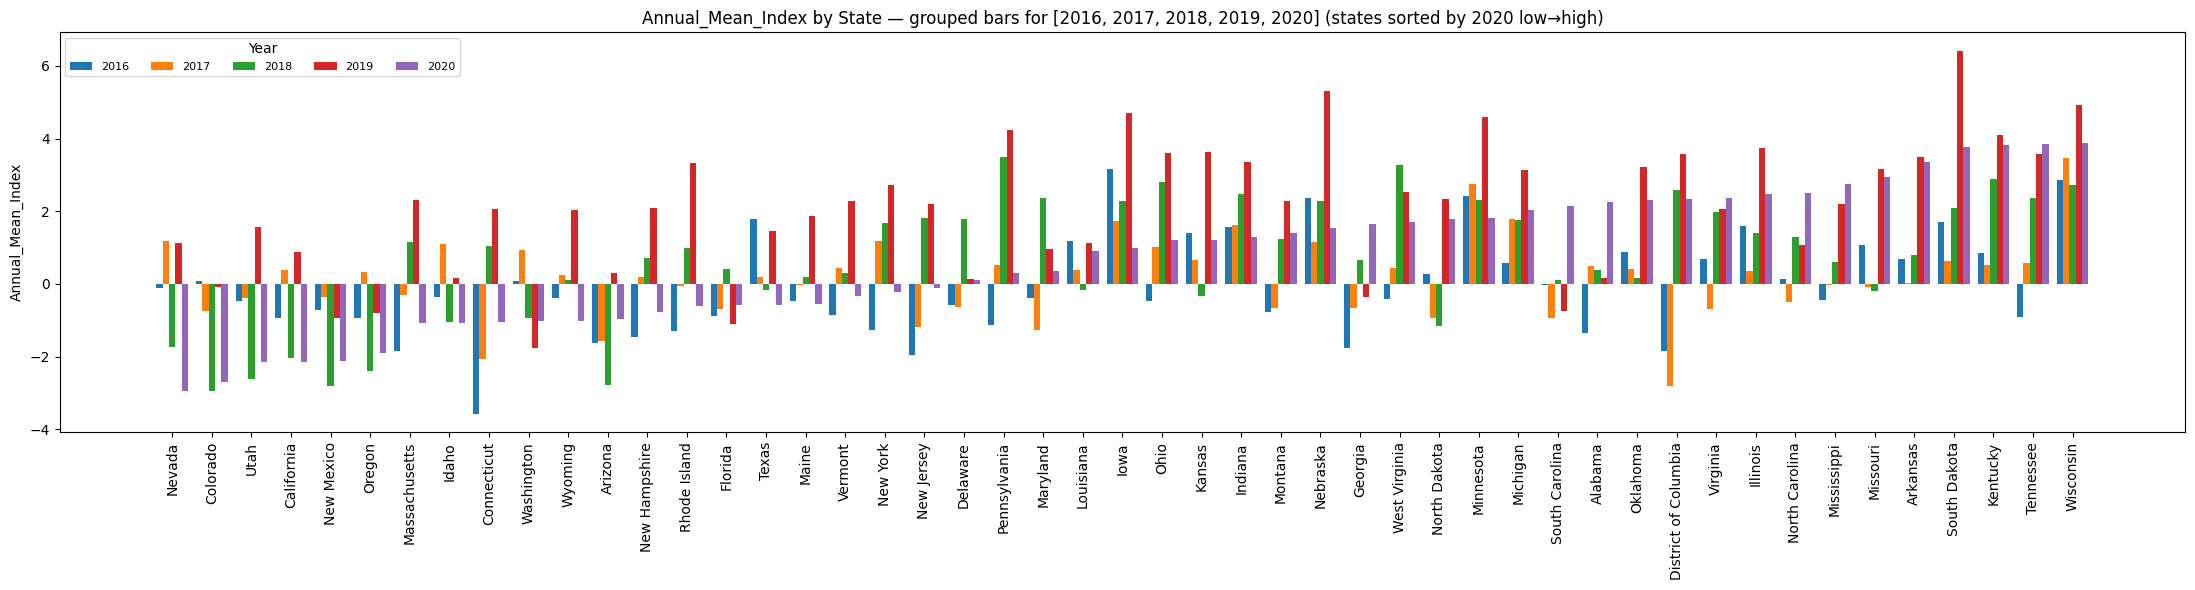

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# === change this to your CSV path ===
csv_path = "/Users/ramilmammadov/Downloads/all merged years/NCEI_annual_drought_county_FINAL.csv"

# Load + prep
df = pd.read_csv(csv_path, usecols=["Year", "State", "Annual_Mean_Index"]).dropna()
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype(int)
df["Annual_Mean_Index"] = pd.to_numeric(df["Annual_Mean_Index"], errors="coerce")

# Mean per state-year
d = df.groupby(["State", "Year"])["Annual_Mean_Index"].mean().reset_index(name="AMI")

# --- PICK YEARS FOR ONE CHART ---
YEARS_TO_PLOT = sorted(d["Year"].unique())[-5:]  # <- last 5 years; change as you like
REF_YEAR = max(YEARS_TO_PLOT)  # <- sort states by this year (low→high)

# Pivot to grouped-bar shape
p = d[d["Year"].isin(YEARS_TO_PLOT)].pivot(index="State", columns="Year", values="AMI")
p = p.dropna(how="all")  # drop states missing all selected years

# Sort states by REF_YEAR (low→high); if missing, push to end
order = p[REF_YEAR].sort_values(na_position="last").index
p = p.loc[order]

# Plot: one chart, grouped bars per state
states = p.index.tolist()
years = YEARS_TO_PLOT
n_states, n_years = len(states), len(years)
x = range(n_states)
bar_width = 0.8 / max(1, n_years)

plt.figure(figsize=(max(12, 0.45 * n_states), 6))
for i, y in enumerate(years):
    vals = p[y].values
    # center groups and offset each year's bar inside the group
    xpos = [xi - 0.4 + i * bar_width + bar_width / 2 for xi in x]
    plt.bar(xpos, vals, width=bar_width, label=str(y))

plt.xticks(list(x), states, rotation=90)
plt.ylabel("Annual_Mean_Index")
plt.title(
    f"Annual_Mean_Index by State — grouped bars for {years} (states sorted by {REF_YEAR} low→high)"
)
plt.legend(title="Year", ncol=min(6, n_years), fontsize=8)
plt.tight_layout()
plt.show()

In [3]:
# Load the dataset
file_name = "/Users/ramilmammadov/Downloads/all merged years/NCEI_annual_drought_county_FINAL.csv"
try:
    df = pd.read_csv(file_name)

    # Inspect the data
    print("Data Info:")
    df.info()

    print("\nData Head:")
    print(df.head())

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65247 entries, 0 to 65246
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FIPS               65247 non-null  int64  
 1   County             65247 non-null  object 
 2   State              65247 non-null  object 
 3   State_abbr         65247 non-null  object 
 4   Year               65247 non-null  int64  
 5   Annual_Mean_Index  65247 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 3.0+ MB

Data Head:
   FIPS          County    State State_abbr  Year  Annual_Mean_Index
0  1001  Autauga County  Alabama         AL  2000              -2.32
1  1001  Autauga County  Alabama         AL  2001               1.43
2  1001  Autauga County  Alabama         AL  2002              -0.76
3  1001  Autauga County  Alabama         AL  2003               2.39
4  1001  Autauga County  Alabama         AL  2004               0.00


In [4]:
import altair as alt

# Load the dataset
file_name = "/Users/ramilmammadov/Downloads/all merged years/NCEI_annual_drought_county_FINAL.csv"
try:
    df = pd.read_csv(file_name)

    # --- Request 1: Faceted Bar Chart (State Means per Year, Sorted) ---

    # Calculate mean index per state per year
    state_mean_df = (
        df.groupby(["Year", "State"])["Annual_Mean_Index"].mean().reset_index()
    )

    # Create the faceted bar chart
    chart1 = (
        alt.Chart(state_mean_df)
        .mark_bar()
        .encode(
            x=alt.X("Annual_Mean_Index", title="Mean Annual Index"),
            y=alt.Y("State", sort="x"),  # Sorts states from lowest to highest index
            color=alt.condition(
                alt.datum.Annual_Mean_Index > 0,
                alt.value("steelblue"),  # Wet
                alt.value("firebrick"),  # Dry
            ),
            row=alt.Row(
                "Year:O", header=alt.Header(titleOrient="top", labelOrient="bottom")
            ),
            tooltip=["Year", "State", "Annual_Mean_Index"],
        )
        .properties(
            title="Mean Annual Drought Index by State for Each Year (Sorted Lowest to Highest)"
        )
        .interactive()
    )  # Make it interactive to handle the large number of facets

    chart1.save("state_year_sorted_bars.json")

    # --- Request 2: Other Interesting Charts ---

    # Chart 2a: Overall Distribution of Annual_Mean_Index
    chart2a = (
        alt.Chart(df)
        .mark_bar()
        .encode(
            alt.X(
                "Annual_Mean_Index",
                bin=alt.Bin(maxbins=50),
                title="Annual Mean Index (Palmer Z-Index)",
            ),
            y=alt.Y("count()", title="Number of County-Year Records"),
            tooltip=[alt.X("Annual_Mean_Index", bin=alt.Bin(maxbins=50)), "count()"],
        )
        .properties(
            title="Distribution of Annual Mean Drought Index (All Counties, 2000-2020)"
        )
        .interactive()
    )

    chart2a.save("index_distribution_hist.json")

    # Chart 2b: Average Drought Index Over Time (National)
    national_mean_df = df.groupby("Year")["Annual_Mean_Index"].mean().reset_index()

    chart2b = (
        alt.Chart(national_mean_df)
        .mark_line(point=True)
        .encode(
            x=alt.X("Year:O", axis=alt.Axis(title="Year")),
            y=alt.Y("Annual_Mean_Index", title="National Average Index"),
            tooltip=["Year", "Annual_Mean_Index"],
        )
        .properties(title="National Average Annual Drought Index (2000-2020)")
        .interactive()
    )

    chart2b.save("national_trend_line.json")

    # Chart 2c: Top 10 Driest and Wettest States (Overall)
    overall_state_mean = df.groupby("State")["Annual_Mean_Index"].mean().reset_index()

    # Get bottom 10 (driest)
    bottom_10 = overall_state_mean.sort_values(
        by="Annual_Mean_Index", ascending=True
    ).head(10)

    # Get top 10 (wettest)
    top_10 = overall_state_mean.sort_values(
        by="Annual_Mean_Index", ascending=False
    ).head(10)

    # Combine them
    top_bottom_states = pd.concat([bottom_10, top_10])

    chart2c = (
        alt.Chart(top_bottom_states)
        .mark_bar()
        .encode(
            x=alt.X("Annual_Mean_Index", title="Overall Mean Index (2000-2020)"),
            y=alt.Y("State", sort="-x"),  # Sort all 20 states from wettest to driest
            color=alt.condition(
                alt.datum.Annual_Mean_Index > 0,
                alt.value("steelblue"),  # Wet
                alt.value("firebrick"),  # Dry
            ),
            tooltip=["State", "Annual_Mean_Index"],
        )
        .properties(
            title="10 Wettest and 10 Driest States (Overall Average, 2000-2020)"
        )
    )

    chart2c.save("top_bottom_states_bar.json")

    print("All charts have been generated and saved as JSON files.")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

All charts have been generated and saved as JSON files.


In [5]:
import seaborn as sns
import numpy as np

# Set base style for seaborn
sns.set_theme(style="whitegrid")

# Define the file name
file_name = "NCEI_annual_drought_county_FINAL.csv"

try:
    # Load the dataset
    df = pd.read_csv(file_name)
    print(f"Successfully loaded '{file_name}'. Starting chart generation...")

    # --- Chart 1: Sorted Bar Chart for 2020 (Request 1, Alternative 1) ---

    # Filter for 2020 and calculate state means
    df_2020 = df[df["Year"] == 2020]
    state_mean_2020 = df_2020.groupby("State")["Annual_Mean_Index"].mean().sort_values()

    # Create color list (red for negative/dry, blue for positive/wet)
    colors_2020 = [
        "firebrick" if x < 0 else "steelblue" for x in state_mean_2020.values
    ]

    # Plot
    plt.figure(figsize=(10, 12))
    state_mean_2020.plot(kind="barh", color=colors_2020)
    plt.title("Mean Annual Drought Index by State for 2020 (Sorted Lowest to Highest)")
    plt.xlabel("Mean Annual Index (Palmer Z-Index)")
    plt.ylabel("State")
    plt.tight_layout()
    plt.savefig("state_year_2020_sorted.png")
    plt.close()  # Close figure to free memory
    print("Generated: state_year_2020_sorted.png")

    # --- Chart 2: Heatmap (Request 1, Alternative 2) ---

    # Pivot the data
    state_year_pivot = (
        df.groupby(["Year", "State"])["Annual_Mean_Index"].mean().reset_index()
    )
    state_year_pivot = state_year_pivot.pivot(
        index="State", columns="Year", values="Annual_Mean_Index"
    )

    # Plot heatmap
    plt.figure(figsize=(16, 12))
    sns.heatmap(
        state_year_pivot,
        cmap="RdBu_r",  # Red (dry) to Blue (wet), reversed
        center=0,  # Center colormap at 0
        annot=False,  # Turn off annotations
    )
    plt.title("Heatmap of Mean Annual Drought Index (State vs. Year)")
    plt.xlabel("Year")
    plt.ylabel("State")
    plt.tight_layout()
    plt.savefig("state_year_heatmap.png")
    plt.close()
    print("Generated: state_year_heatmap.png")

    # --- Chart 3: Overall Distribution (Request 2a) ---

    plt.figure(figsize=(10, 6))
    sns.histplot(df["Annual_Mean_Index"], bins=50, kde=True, color="midnightblue")
    plt.title("Distribution of Annual Mean Drought Index (All Counties, 2000-2020)")
    plt.xlabel("Annual Mean Index (Palmer Z-Index)")
    plt.ylabel("Number of County-Year Records")
    plt.tight_layout()
    plt.savefig("index_distribution_hist.png")
    plt.close()
    print("Generated: index_distribution_hist.png")

    # --- Chart 4: Average Drought Index Over Time (National) (Request 2b) ---

    national_mean_df = df.groupby("Year")["Annual_Mean_Index"].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=national_mean_df,
        x="Year",
        y="Annual_Mean_Index",
        marker="o",
        color="black",
    )
    # Add a horizontal line at 0
    plt.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    plt.title("National Average Annual Drought Index (2000-2020)")
    plt.xlabel("Year")
    plt.ylabel("National Average Index")
    # Ensure all year ticks are shown
    plt.xticks(national_mean_df["Year"].unique(), rotation=45)
    plt.tight_layout()
    plt.savefig("national_trend_line.png")
    plt.close()
    print("Generated: national_trend_line.png")

    # --- Chart 5: Top 10 Driest and Wettest States (Overall) (Request 2c) ---

    overall_state_mean = df.groupby("State")["Annual_Mean_Index"].mean().reset_index()

    # Get bottom 10 (driest)
    bottom_10 = overall_state_mean.sort_values(
        by="Annual_Mean_Index", ascending=True
    ).head(10)
    # Get top 10 (wettest)
    top_10 = overall_state_mean.sort_values(
        by="Annual_Mean_Index", ascending=False
    ).head(10)
    # Combine and sort them for plotting
    top_bottom_states = pd.concat([bottom_10, top_10]).sort_values("Annual_Mean_Index")

    # Create color list (red for negative/dry, blue for positive/wet)
    colors_top_bottom = [
        "firebrick" if x < 0 else "steelblue"
        for x in top_bottom_states["Annual_Mean_Index"]
    ]

    plt.figure(figsize=(10, 8))
    # Use seaborn barplot and pass the custom color list to 'palette'
    sns.barplot(
        data=top_bottom_states,
        x="Annual_Mean_Index",
        y="State",
        palette=colors_top_bottom,
    )
    plt.title("10 Wettest and 10 Driest States (Overall Average, 2000-2020)")
    plt.xlabel("Overall Mean Index (2000-2020)")
    plt.ylabel("State")
    plt.tight_layout()
    plt.savefig("top_bottom_states_bar.png")
    plt.close()
    print("Generated: top_bottom_states_bar.png")

    print("\nAll 5 chart files have been generated successfully.")

except FileNotFoundError:
    print(
        f"Error: The file '{file_name}' was not found. Please ensure it's in the correct directory."
    )
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded 'NCEI_annual_drought_county_FINAL.csv'. Starting chart generation...
Generated: state_year_2020_sorted.png
Generated: state_year_heatmap.png
Generated: index_distribution_hist.png
Generated: national_trend_line.png
Generated: top_bottom_states_bar.png

All 5 chart files have been generated successfully.


/var/folders/fh/f76kx5296m59wrx1dwbdp9q00000gn/T/ipykernel_5014/1901699160.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set base style for seaborn
sns.set_theme(style="whitegrid")

# Define the file name
file_name = "NCEI_annual_drought_county_FINAL.csv"

try:
    # Load the dataset
    df = pd.read_csv(file_name)
    print(f"Successfully loaded '{file_name}'. Regenerating heatmap...")

    # --- Updated Heatmap Code ---

    # Pivot the data
    state_year_pivot = (
        df.groupby(["Year", "State"])["Annual_Mean_Index"].mean().reset_index()
    )
    state_year_pivot = state_year_pivot.pivot(
        index="State", columns="Year", values="Annual_Mean_Index"
    )

    # Plot heatmap
    plt.figure(figsize=(16, 12))
    sns.heatmap(
        state_year_pivot,
        cmap="RdBu",  # Corrected: 'RdBu' maps low (neg) to Red and high (pos) to Blue
        center=0,
        annot=False,
    )
    plt.title("Heatmap of Mean Annual Drought Index (State vs. Year)")
    plt.xlabel("Year")
    plt.ylabel("State")
    plt.tight_layout()
    # Save as a new file to avoid confusion
    plt.savefig("state_year_heatmap_updated.png")
    plt.close()

    print(
        "\nHeatmap has been regenerated as 'state_year_heatmap_updated.png' with the corrected color scheme."
    )

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded 'NCEI_annual_drought_county_FINAL.csv'. Regenerating heatmap...

Heatmap has been regenerated as 'state_year_heatmap_updated.png' with the corrected color scheme.
